In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

clientes = pd.DataFrame({ "saldo": [ 50000, 45000, 48000, 43500, 47000, 52000,
                                     20000, 26000, 25000, 23000, 21400, 18000,
                                     8000, 12000, 6000, 14500, 12600, 7000],
                        
                          "transacciones": [25, 20, 16, 23, 25, 18,
                                            23, 22, 24, 21, 27, 18,
                                             8, 3, 6, 4, 9, 3]
                        })

Hacemos el escalamiento que se encargará de ajustar nuestros datos determinando cuál sería nuestro nuevo mínimo y
nuestro nuevo máximo para, conservando la misma información, tener todos los datos dentro del rango 0(cero) y 1(uno) 

In [53]:
escalador = MinMaxScaler().fit(clientes.values)

Generamos nuevamente nuestro DF pero va a ser un nuevo df ya con los valores preprocesados

In [54]:
clientes = pd.DataFrame( escalador.transform( clientes.values ),
                       columns=[ "saldo", "transacciones"])

clientes



,saldo,transacciones
0,0.956522,0.916667
1,0.847826,0.708333
2,0.913043,0.541667
3,0.815217,0.833333
4,0.891304,0.916667
5,1.000000,0.625000
6,0.304348,0.833333
7,0.434783,0.791667
8,0.413043,0.875000
9,0.369565,0.750000


In [55]:
kmeans = KMeans( n_clusters=5 ).fit( clientes.values )
clientes["cluster"] = kmeans.labels_


C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [56]:
print( kmeans.cluster_centers_, kmeans.inertia_)

[[0.88768116 0.88888889]
 [0.06231884 0.19444444]
 [0.35289855 0.8125    ]
 [0.92028986 0.625     ]
 [0.11231884 0.01388889]] 0.17479540800252052


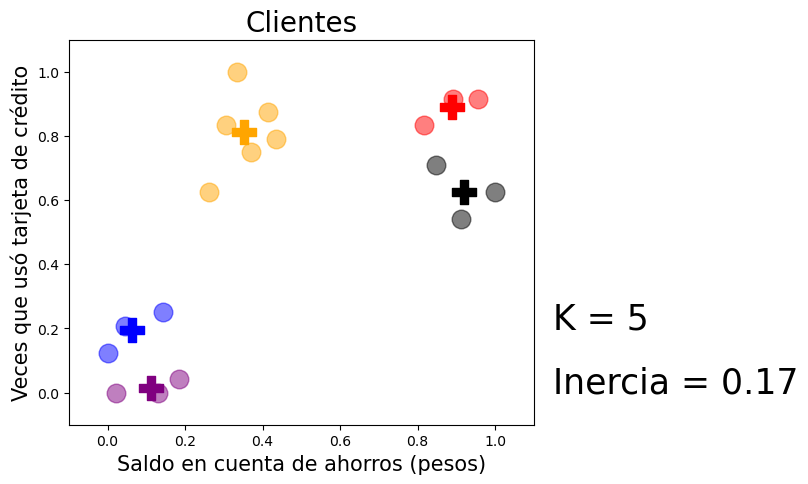

In [57]:
# Instrucciones para graficar los Clusters

# Indico tamaño y resolución de la figura
plt.figure( figsize=( 6, 5), dpi= 100)
# Colores que voy a utilizar para graficar cada uno de mis clusters
colores = ["red", "blue", "orange", "black", "purple", "pink", "brown"]
# Utilizamos dos gráficas de dispersión, la primera para graficar cada uno de mis clusters utilizando diferentes colores
for cluster in range( kmeans.n_clusters):
     plt.scatter( clientes[clientes["cluster"] == cluster]["saldo"],
                 clientes[clientes["cluster"] == cluster]["transacciones"],
                 marker = "o", s= 180, color= colores[ cluster ], alpha= 0.5)
# La otra grafica de dispersion la utilizaremos con nuestros centroides
     plt.scatter( kmeans.cluster_centers_[ cluster ] [0],
                  kmeans.cluster_centers_[ cluster ] [1],
                  marker="P", s=280, color= colores[ cluster ])

# El resto es para estilar la gráfica
plt.title("Clientes", fontsize= 20 )
plt.xlabel("Saldo en cuenta de ahorros (pesos)", fontsize = 15)
plt.ylabel("Veces que usó tarjeta de crédito", fontsize= 15)
plt.text(1.15, 0.2, "K = %i" % kmeans.n_clusters, fontsize= 25)
plt.text(1.15,0, "Inercia = %0.2f" % kmeans.inertia_, fontsize= 25)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()


## Método del Codo

Cálculo del número de Clusters(K)

C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the e

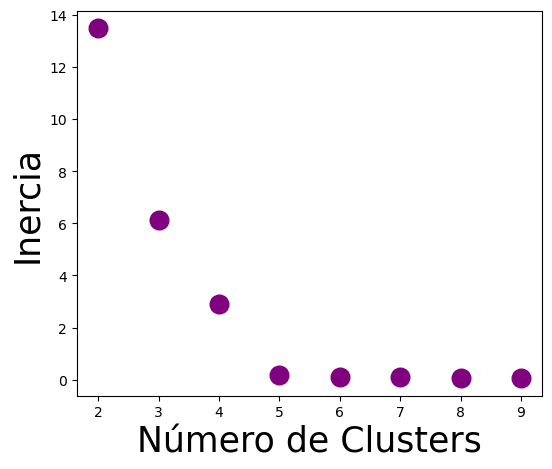

In [64]:
inercias = []
for k in range ( 2, 10 ):
    kmeans = KMeans( n_clusters=k).fit(clientes.values)
    inercias.append(kmeans.inertia_)
    
plt.figure(figsize=(6, 5), dpi=100)
plt.scatter(range (2, 10), inercias, marker= "o", s=180, color="purple")
plt.xlabel("Número de Clusters", fontsize= 25)
plt.ylabel("Inercia", fontsize= 25)
plt.show()